In [1]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import os
import json
from tqdm import tqdm


from CityScapes import PreprocessedCityscapesDataset
from file_management import get_version_folder, save_config, load_config
from model import Model,init_weights, Augmentations


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
root = 'cache'
index_folder = get_version_folder(root)
config = load_config('hyperparameters.yaml')
config['learning']['model_path'] = os.path.join(index_folder, 'model.pth')

config_target_path = os.path.join(index_folder,'config.yaml')
save_config(config, config_target_path)

augmentations= Augmentations(**config['learning']['Augmentations'])


Config saved to cache/74/config.yaml


In [3]:
train_dataset = PreprocessedCityscapesDataset(get_labels=False)
train_dataloader = DataLoader(train_dataset, batch_size=config['learning']['batch_size'], shuffle=True)

model = Model(**config['model']).to(device)
# model.apply(init_weights)

optimizer = config['learning']['optimizer'](model.parameters(), lr=config['learning']['lr'])
reconstruction_loss_fn = config['learning']['loss_fn']
segmentation_loss_fn =config['learning']['segmentation_loss']

vector_similarity_loss_fn = config['learning']['vector_similarity_loss']

losses_list= []


In [4]:
import torch

def get_best_reconstruction_mask(recs, targets):
    """
    Finds the 'closest' reconstruction per pixel and returns a binary mask.
    
    Args:
        recs: (B, N, C, H, W) - The N candidate reconstructions
        targets: (B, C, H, W) - The ground truth images
        
    Returns:
        mask: (B, N, H, W) - Binary tensor (dtype=torch.float32)
    """
    # 1. Align shapes for broadcasting
    # recs:    (B, N, C, H, W)
    # targets: (B, 1, C, H, W)
    targets = targets.unsqueeze(1)
    
    # 2. Calculate Squared Euclidean Distance (L2 Norm squared)
    # Summing over the channel dimension (C) at index 2
    # result shape: (B, N, H, W)
    dist = torch.pow(recs - targets, 2).sum(dim=2)
    
    # 3. Identify the index of the best reconstruction for every pixel
    # argmin returns the index (0 to N-1) across the N dimension
    # shape: (B, H, W)
    indices = torch.argmin(dist, dim=1)
    
    # 4. Create the binary mask (B, N, H, W)
    # We use a comparison broadcaσst to create the 1s and 0s
    # View indices as (B, 1, H, W) to compare against a range of N
    N = recs.shape[1]
    n_range = torch.arange(N, device=recs.device).view(1, N, 1, 1)
    
    mask = (indices.unsqueeze(1) == n_range).float()
    
    return mask

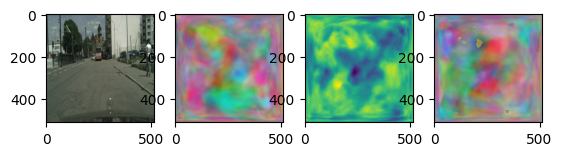

In [5]:

x= next(iter(train_dataloader))
# x = augmentations(x)
x= x.to(device)
rec, seg, vectors = model(x)
final_reconstruction = model.reconstruct_image(rec, seg, binary_masks=True)


fig,ax = plt.subplots(1,4)
ax[0].imshow(x.detach().cpu()[0].permute(1,2,0))
ax[1].imshow(rec.detach().cpu()[0,0].permute(1,2,0))
ax[2].imshow(seg.detach().cpu()[0,0])
ax[3].imshow(final_reconstruction.detach().cpu()[0].permute(1,2,0))

In [11]:
epochs = 1

for epoch in range(epochs):
    loop = tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{epochs}')
    # loop = tqdm(range(len(train_dataloader)))
    for batch in loop:
        optimizer.zero_grad()
        batch = batch.to(device)
        # batch=  augmentations(batch)
        rec, seg, vectors = model(batch)
        final_reconstruction = model.reconstruct_image(rec, seg, binary_masks=True)
        # reconstruction loss
        # final_reconstruction = rec[:,0]
        loss = reconstruction_loss_fn(final_reconstruction, batch)

        # loss += vector_similarity_loss_fn(vectors)


        with torch.no_grad():
            one_hot_segmentation_target = get_best_reconstruction_mask(rec, batch)
            segmentation_target = torch.argmax(one_hot_segmentation_target, dim=1) # Shape becomes [B, H, W]
        loss += segmentation_loss_fn(seg, segmentation_target)
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=loss.item(),w=model.encoder.encoder[0].conv.weight[0,0,0,0].item(), v=model.reconstruction_decoder.vectorizers[0].vectors[0, 0].item())
        losses_list.append(loss.item())
                                                                            
    torch.save(model.state_dict(), config['learning']['model_path'])

Epoch 1/1:   8%|▊         | 832/9999 [02:13<24:31,  6.23it/s, loss=0.726, v=0.908, w=-0.00925]


KeyboardInterrupt: 

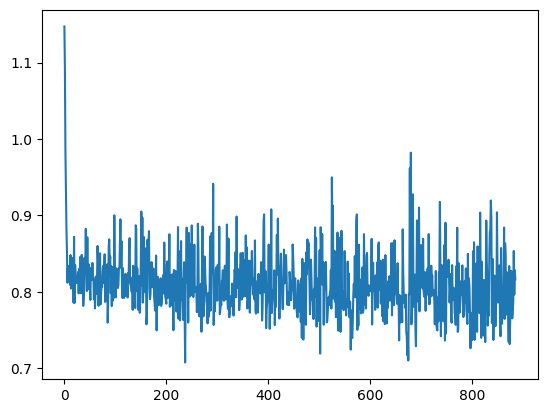

In [7]:
plt.plot(losses_list)


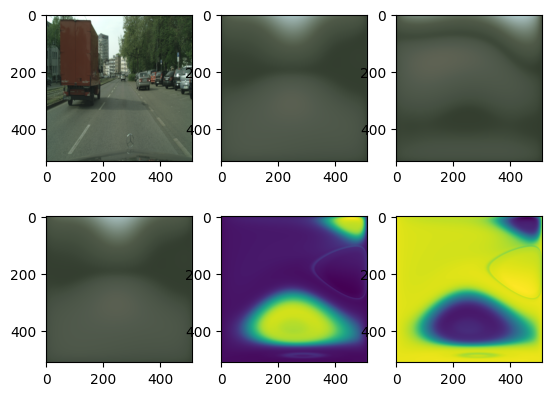

In [14]:

# x= next(iter(train_dataloader))

x= x.to(device)
rec, seg, vectors = model(x)
seg = nn.Softmax(dim=1)(seg)
final_reconstruction = model.reconstruct_image(rec, seg, binary_masks=True)


show=  1
components = seg.shape[1]

fig,ax = plt.subplots(2,components+1)
ax[0,0].imshow(x.detach().cpu()[show].permute(1,2,0))
ax[1,0].imshow(final_reconstruction.detach().cpu()[show].permute(1,2,0))

for i in range(components):
    ax[0,i+1].imshow(rec.detach().cpu()[show,i].permute(1,2,0))
    ax[1,i+1].imshow(seg.detach().cpu()[show,i])
                                                                                                                                                                                                                                                
